## Utility notebook: per-box evaluation summaries

This archival notebook aggregates CSV and Excel outputs from the evaluation stage. The filename parsing logic is intentionally kept close to the original because downstream file naming is fragile.

In [ ]:
from pathlib import Path
import re
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import pandas as pd

# Advanced users: edit these paths directly in this notebook.
ROOT_PATH = Path("/home/vasakjakub/fenotypizace")
DATA_ROOT = ROOT_PATH / "data"
EVALUATION_DIR = DATA_ROOT / "evaluation"
MERGED_REPORT_PATH = (
    DATA_ROOT / "processed" / "evaluace_relearned_org" / "report" / "MERGE_report.xlsx"
)

plt.style.use("default")

print("Repo root:", ROOT_PATH)
print("Evaluation dir:", EVALUATION_DIR)
print("Merged report path:", MERGED_REPORT_PATH)

In [ ]:
def extract_info(name: str) -> tuple[str | None, str | None, datetime | None]:
    pattern = r"(\d+)_(\d+-\d+-\d+-\d+-\d+-\d+)_(\d+-\d+)\.png"
    match = re.match(pattern, name)
    if match:
        tray_id = match.group(1)
        datetime_str = match.group(2)
        box_id = match.group(3)
        datetime_obj = datetime.strptime(datetime_str, "%d-%m-%y-%H-%M-%S")
        return tray_id, box_id, datetime_obj
    return None, None, None

In [ ]:
def find_first_event(
    df: pd.DataFrame,
    series_id: tuple[str, str],
    criterion: str = "annot",
) -> datetime | None:
    series_data = df[(df["idtray"] == series_id[0]) & (df["idbox"] == series_id[1])]
    germination_times = series_data[series_data[criterion] == 1]["datetime"]
    return min(germination_times) if not germination_times.empty else None

In [ ]:
def summarize_predictions(dataframes: list[pd.DataFrame]) -> list[dict[str, int]]:
    summaries: list[dict[str, int]] = []
    for df in dataframes:
        summary = {"Earlier": 0, "Later": 0, "On Time": 0}
        unique_series = df[["idtray", "idbox"]].drop_duplicates()
        for _, series in unique_series.iterrows():
            series_id = (series["idtray"], series["idbox"])
            ground_truth_time = find_first_event(df, series_id, "annot")
            prediction_time = find_first_event(df, series_id, "cprob")
            if ground_truth_time and prediction_time:
                if prediction_time < ground_truth_time:
                    summary["Earlier"] += 1
                elif prediction_time > ground_truth_time:
                    summary["Later"] += 1
                else:
                    summary["On Time"] += 1
        summaries.append(summary)
    return summaries

In [ ]:
def summarize_predictions_with_tolerance(
    dataframes: list[pd.DataFrame],
) -> list[dict[str, int]]:
    summaries: list[dict[str, int]] = []
    for df in dataframes:
        summary = {"Earlier": 0, "Later": 0, "On Time": 0}
        unique_series = df[["idtray", "idbox"]].drop_duplicates()
        for _, series in unique_series.iterrows():
            series_id = (series["idtray"], series["idbox"])
            ground_truth_time = find_first_event(df, series_id, "annot")
            prediction_time = find_first_event(df, series_id, "cprob")
            if ground_truth_time and prediction_time:
                if prediction_time < ground_truth_time - timedelta(hours=2):
                    summary["Earlier"] += 1
                elif prediction_time > ground_truth_time + timedelta(hours=2):
                    summary["Later"] += 1
                else:
                    summary["On Time"] += 1
        summaries.append(summary)
    return summaries

In [ ]:
def remove_evaluation_prefix(filename: str) -> str:
    """
    Removes 'Evaluation_results_' prefix from a filename.

    Args:
        filename (str): Original filename

    Returns:
        str: Filename without the prefix
    """
    prefix = "Evaluation_results_"
    if filename.startswith(prefix):
        return filename[len(prefix) :]
    return filename

In [ ]:
csv_path = str(EVALUATION_DIR)

new_file_paths = []
all_file_names = []

for path in EVALUATION_DIR.iterdir():
    if path.is_file() and path.suffix == ".csv":
        new_file_paths.append(str(path))
        all_file_names.append(remove_evaluation_prefix(path.stem))

In [15]:
print(new_file_paths)
print(all_file_names)

['/home/vasakjakub/emergence-detection/data/evaluation/Evaluation_results_ef2_tcn_2-8_org_nab_train_relearned.csv']
['ef2_tcn_2-8_org_nab_train_relearned']


In [ ]:
# Load all files into DataFrames
all_dataframes = [pd.read_csv(path) for path in new_file_paths]

# Extract and add the parsed tray, box, and timestamp information
for df in all_dataframes:
    parsed_info = [extract_info(name) for name in df["names"]]
    if parsed_info:
        tray_ids, box_ids, datetimes = zip(*parsed_info, strict=True)
        df["idtray"] = tray_ids
        df["idbox"] = box_ids
        df["datetime"] = datetimes

all_summaries = [summarize_predictions([df]) for df in all_dataframes]
all_summaries_tolerance = [
    summarize_predictions_with_tolerance([df]) for df in all_dataframes
]

all_summaries, all_summaries_tolerance

([[{'Earlier': 89, 'Later': 111, 'On Time': 222}]],
 [[{'Earlier': 67, 'Later': 69, 'On Time': 286}]])

In [ ]:
# Color palette for the plotted categories
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# Prepare data for plotting (without tolerance and with tolerance)
combined_summaries_all = []
for i, file_name in enumerate(all_file_names):
    combined_summary = {
        "File": file_name,
        "Earlier": all_summaries[i][0]["Earlier"],
        "Later": all_summaries[i][0]["Later"],
        "On Time": all_summaries[i][0]["On Time"],
        "Earlier with Tolerance": all_summaries_tolerance[i][0]["Earlier"],
        "Later with Tolerance": all_summaries_tolerance[i][0]["Later"],
        "On Time with Tolerance": all_summaries_tolerance[i][0]["On Time"],
    }
    combined_summaries_all.append(combined_summary)

all_summary_df = pd.DataFrame(combined_summaries_all)
all_summary_df = all_summary_df.set_index("File")

In [ ]:
def summarize_predictions_with_four_hour_tolerance(
    dataframes: list[pd.DataFrame],
) -> list[dict[str, int]]:
    summaries: list[dict[str, int]] = []
    for df in dataframes:
        summary = {"Earlier": 0, "Later": 0, "On Time": 0}
        unique_series = df[["idtray", "idbox"]].drop_duplicates()
        for _, series in unique_series.iterrows():
            series_id = (series["idtray"], series["idbox"])
            ground_truth_time = find_first_event(df, series_id, "annot")
            prediction_time = find_first_event(df, series_id, "cprob")
            if ground_truth_time and prediction_time:
                if prediction_time < ground_truth_time - timedelta(hours=4):
                    summary["Earlier"] += 1
                elif prediction_time > ground_truth_time + timedelta(hours=4):
                    summary["Later"] += 1
                else:
                    summary["On Time"] += 1
        summaries.append(summary)
    return summaries


all_summary_df["Total Non-On-Time"] = (
    all_summary_df["Earlier"] + all_summary_df["Later"]
)

sorted_all_summary_df = all_summary_df.sort_values("On Time")

all_summaries_four_hour_tolerance = [
    summarize_predictions_with_four_hour_tolerance([df]) for df in all_dataframes
]

for i in range(len(all_file_names)):
    all_summary_df.loc[all_file_names[i], "On Time with Four Hour Tolerance"] = (
        all_summaries_four_hour_tolerance[i][0]["On Time"]
    )

sorted_all_summary_df = all_summary_df.sort_values("On Time")

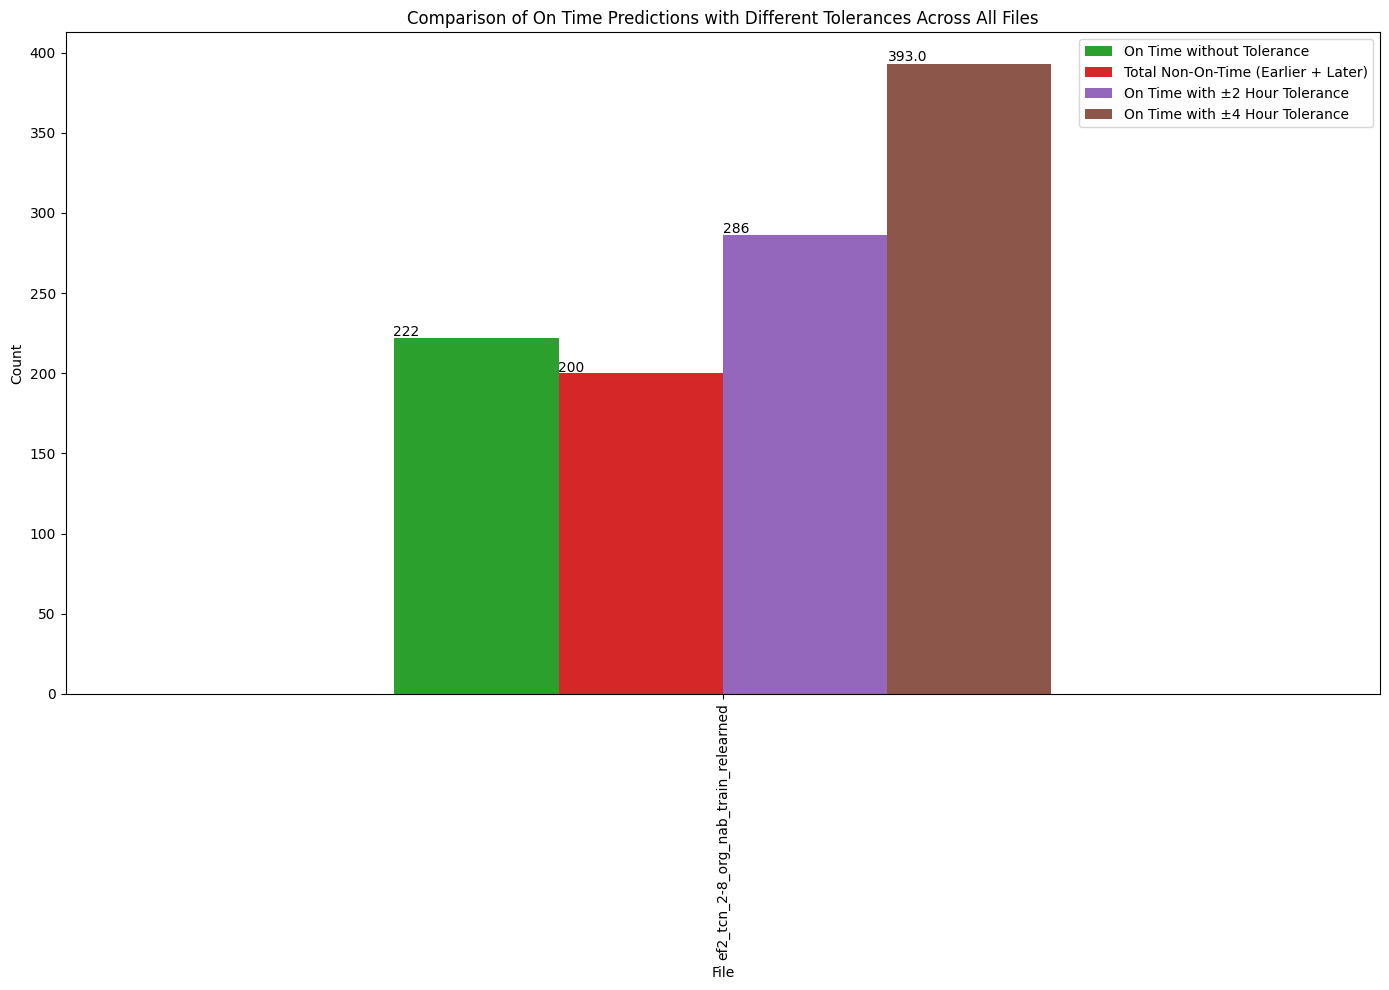

In [ ]:
def summarize_predictions_with_four_hour_tolerance(
    dataframes: list[pd.DataFrame],
) -> list[dict[str, int]]:
    summaries: list[dict[str, int]] = []
    for df in dataframes:
        summary = {"Earlier": 0, "Later": 0, "On Time": 0}
        unique_series = df[["idtray", "idbox"]].drop_duplicates()
        for _, series in unique_series.iterrows():
            series_id = (series["idtray"], series["idbox"])
            ground_truth_time = find_first_event(df, series_id, "annot")
            prediction_time = find_first_event(df, series_id, "cprob")
            if ground_truth_time and prediction_time:
                if prediction_time < ground_truth_time - timedelta(hours=4):
                    summary["Earlier"] += 1
                elif prediction_time > ground_truth_time + timedelta(hours=4):
                    summary["Later"] += 1
                else:
                    summary["On Time"] += 1
        summaries.append(summary)
    return summaries


all_summaries_four_hour_tolerance = [
    summarize_predictions_with_four_hour_tolerance([df]) for df in all_dataframes
]

for i in range(len(all_file_names)):
    all_summary_df.loc[all_file_names[i], "On Time with Four Hour Tolerance"] = (
        all_summaries_four_hour_tolerance[i][0]["On Time"]
    )

sorted_all_summary_df = all_summary_df.sort_values("On Time")

fig, ax = plt.subplots(figsize=(14, 10))
bars = sorted_all_summary_df[
    [
        "On Time",
        "Total Non-On-Time",
        "On Time with Tolerance",
        "On Time with Four Hour Tolerance",
    ]
].plot(kind="bar", ax=ax, color=["#2ca02c", "#d62728", "#9467bd", "#8c564b"])
ax.set_title(
    "Comparison of On Time Predictions with Different Tolerances Across All Files"
)
ax.set_xlabel("File")
ax.set_ylabel("Count")
ax.set_xticklabels(sorted_all_summary_df.index, rotation=90, ha="center")

for patch in bars.patches:
    ax.annotate(
        str(patch.get_height()),
        (patch.get_x() * 1.005, patch.get_height() * 1.005),
    )

plt.legend(
    [
        "On Time without Tolerance",
        "Total Non-On-Time (Earlier + Later)",
        "On Time with ±2 Hour Tolerance",
        "On Time with ±4 Hour Tolerance",
    ]
)
plt.tight_layout()
plt.show()

## Excel report comparison

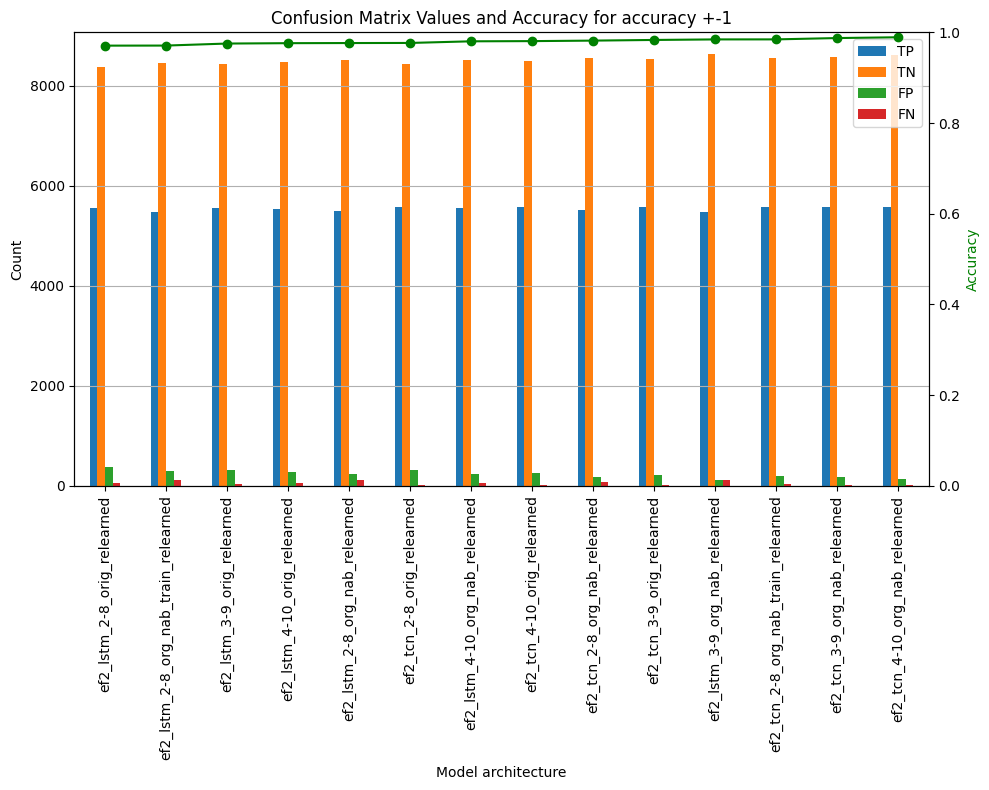

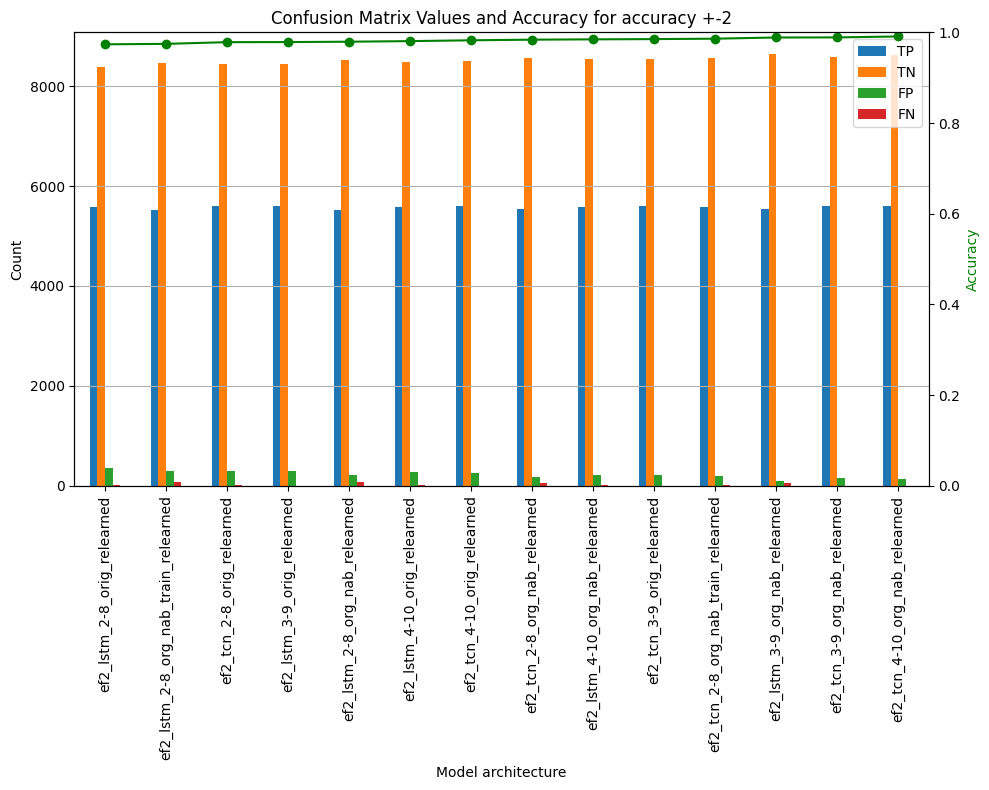

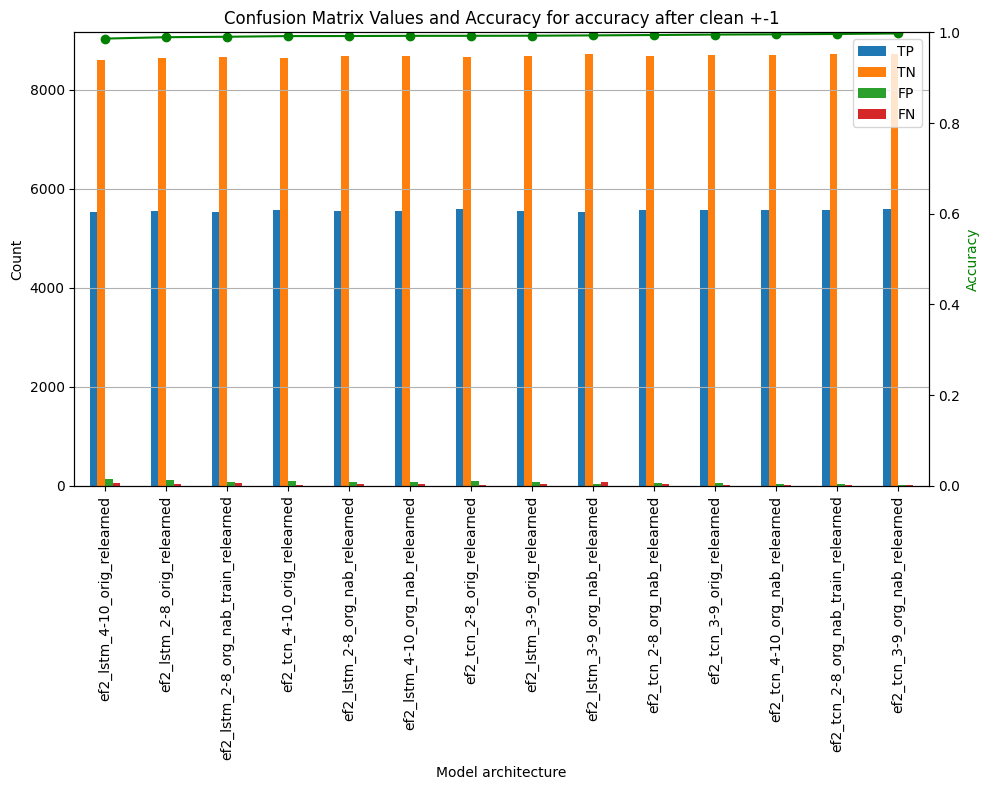

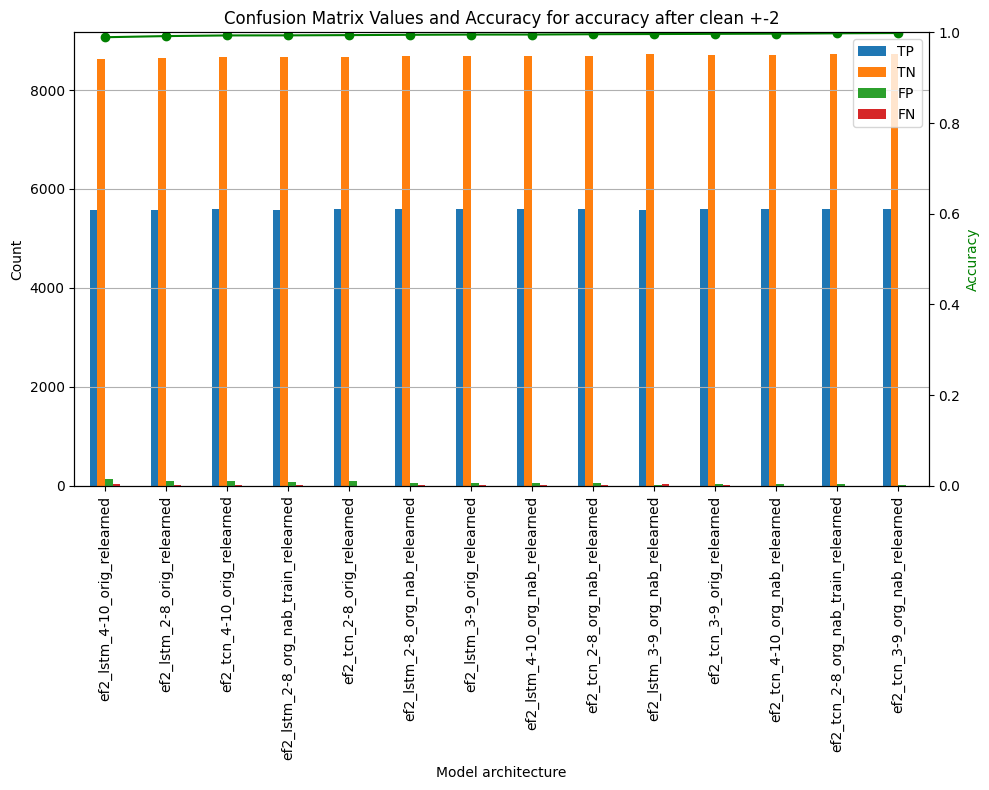

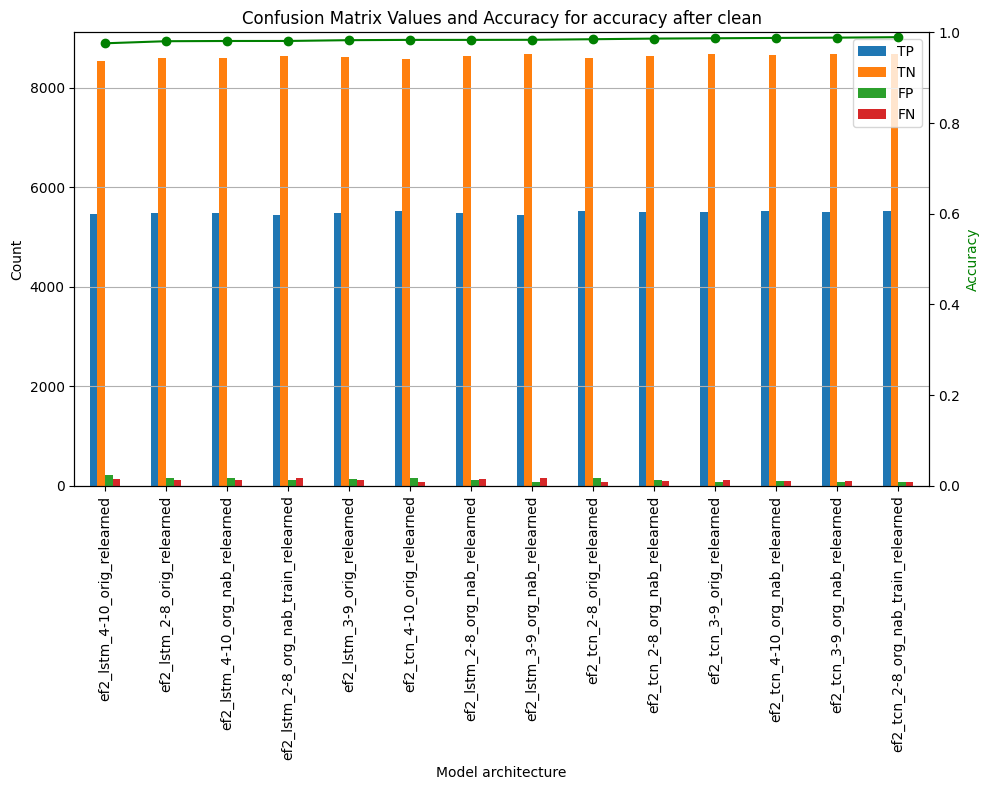

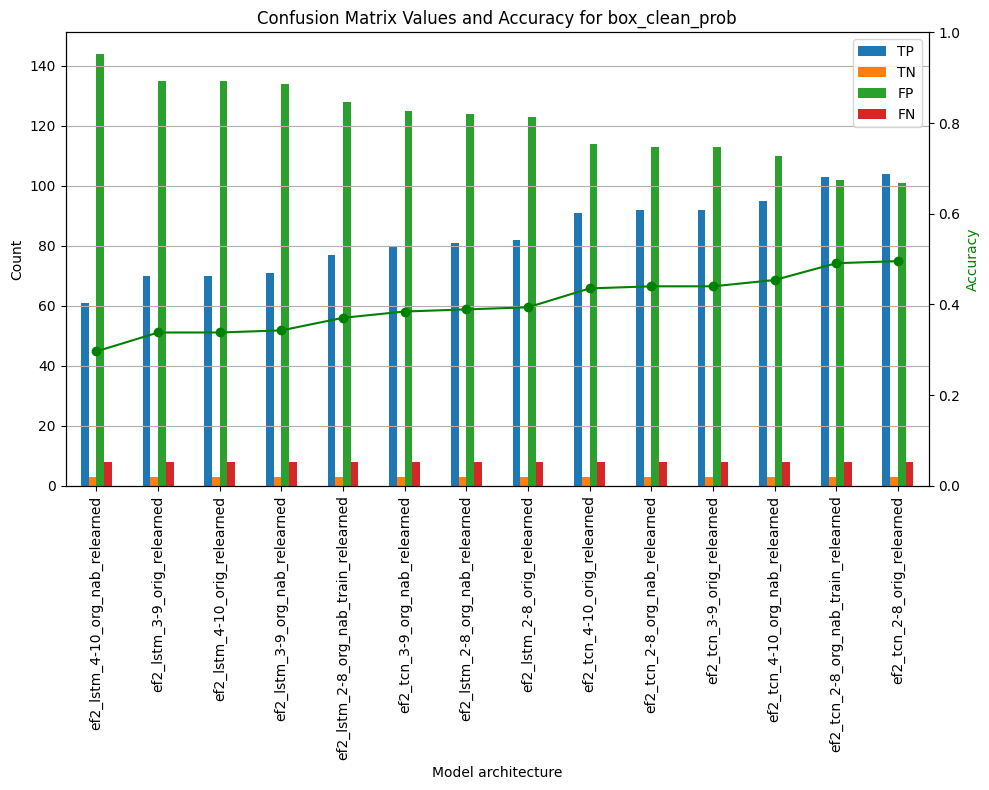

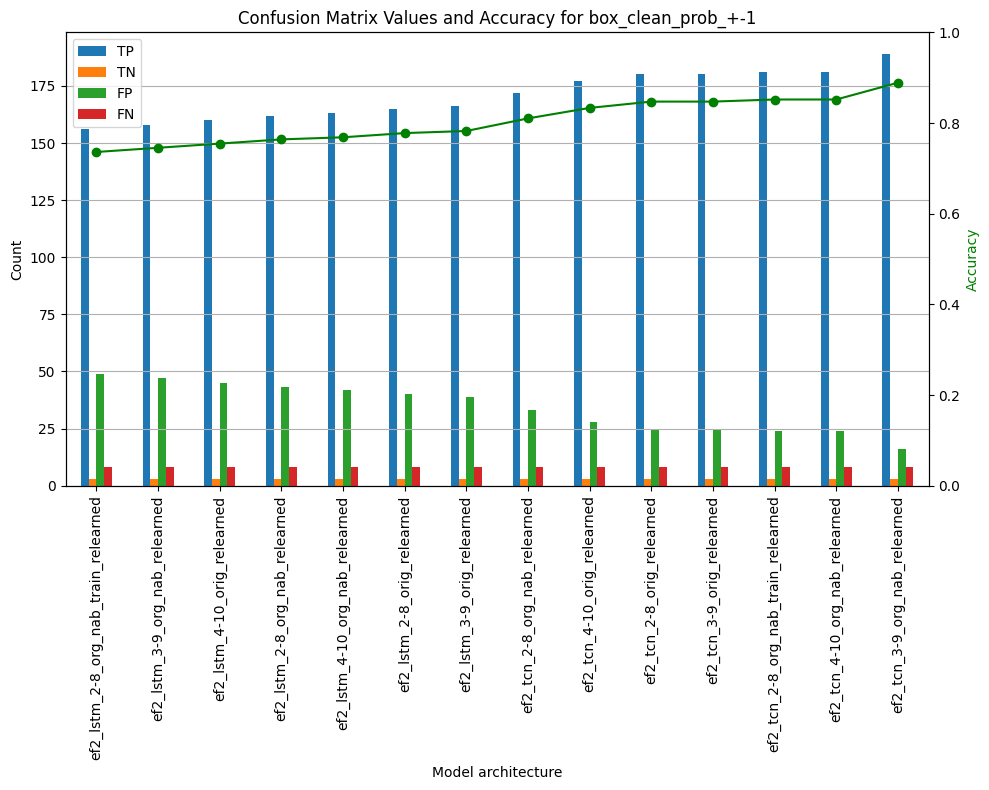

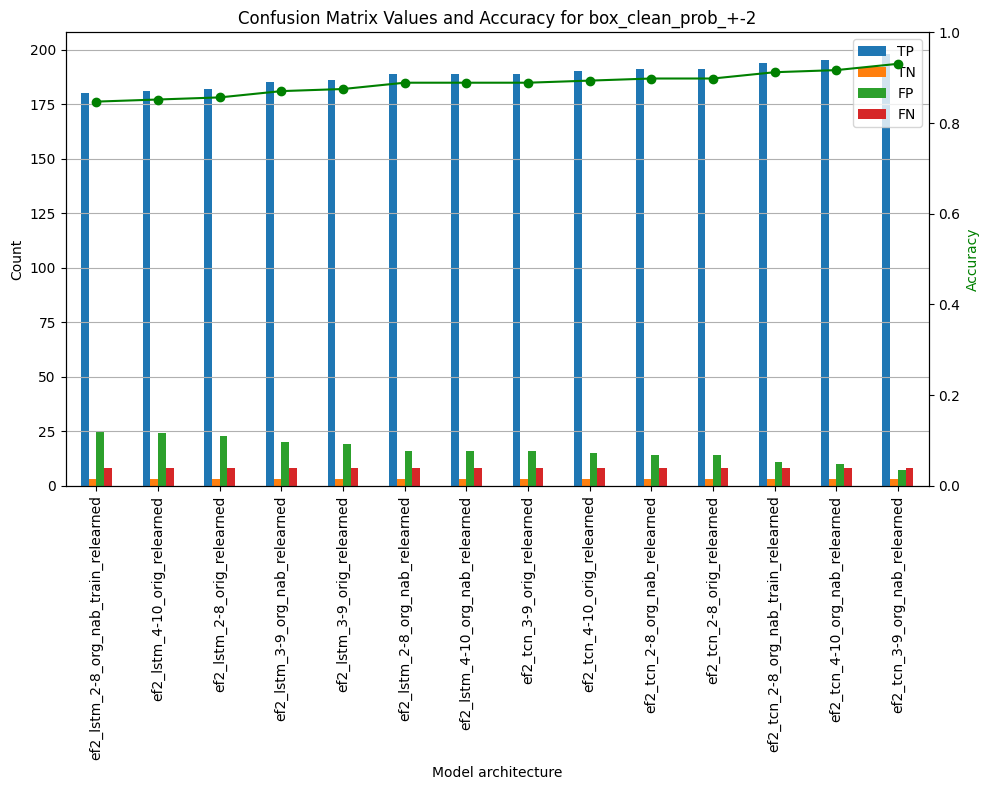

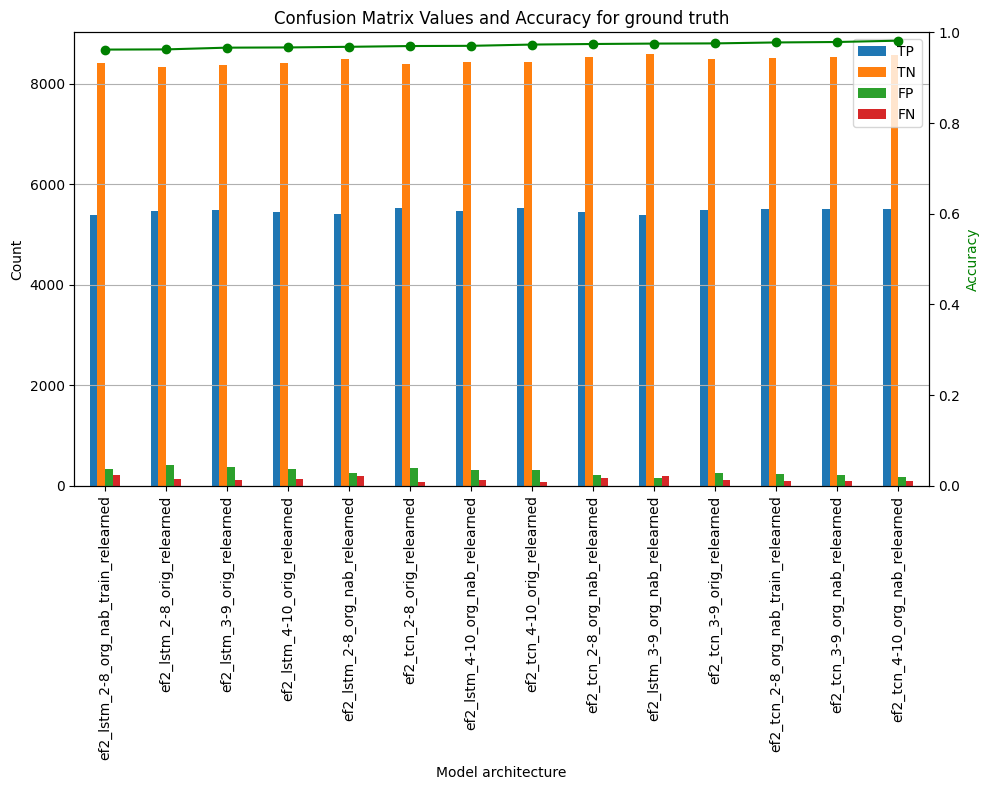

In [ ]:
def load_excel_sheets(file_path: Path) -> dict[str, pd.DataFrame]:
    """Load all sheets from an Excel file."""
    xls = pd.ExcelFile(file_path)
    return {
        sheet_name: pd.read_excel(xls, sheet_name) for sheet_name in xls.sheet_names
    }


def process_data(df: pd.DataFrame) -> pd.DataFrame:
    """Prepare one sheet for plotting."""
    df = df.sort_values("Accuracy")
    return df[["Name", "TP", "TN", "FP", "FN", "Accuracy"]]


def plot_data(
    df: pd.DataFrame,
    sheet_name: str,
    save_plots: bool = False,
) -> None:
    """Create and optionally save bar plots for the given dataframe."""
    _fig, ax1 = plt.subplots(figsize=(10, 8))

    df.set_index("Name")[["TP", "TN", "FP", "FN"]].plot(kind="bar", ax=ax1)
    ax1.set_title(f"Confusion Matrix Values and Accuracy for {sheet_name}")
    ax1.set_ylabel("Count")
    ax1.set_xlabel("Model architecture")
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
    ax1.yaxis.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(df["Name"], df["Accuracy"], color="green", marker="o")
    ax2.set_ylabel("Accuracy", color="green")
    ax2.set_ylim([0, 1])  # type: ignore

    plt.tight_layout()
    if save_plots:
        plt.savefig(f"{sheet_name}_combined_plot.png")
    plt.show()


def main(file_path: Path, save_plots: bool = False) -> None:
    """Load data, process it, and create plots."""
    for sheet_name, df in load_excel_sheets(file_path).items():
        processed_data = process_data(df)
        plot_data(processed_data, sheet_name, save_plots=save_plots)


file_path = MERGED_REPORT_PATH
main(file_path, save_plots=False)